# Mushroom Classification ML
Source: https://www.kaggle.com/datasets/zedsden/mushroom-classification-dataset

In [1]:
#!/usr/bin/env python
# coding: utf-8https://www.kaggle.com/datasets/zedsden/mushroom-classification-dataset

# # After installation, comment this cell and restart the kernel
# !pip3 install pandas pillow imagehash matplotlib scikit-learn torch torchvision imblearn


# ### TODO/PLAN:
# 
# ##### EDA:
# Show brightness, resolution, quality distribution
# 
# For each class, need to do augmentation, 
# i.e. 
# - 1 image -> flip -> another img (for deadly - 692 images)
# - 1 image -> rotation -> another img (for deadly - 692 images)
# - 1 image -> color jittering -> another img (for deadly - 692 images)
#   
# total we have 2,768 images for dealy to train\
# Create different transformer for each augmentation step.
# 
# Undersample majority classes to like 2,768 images using random selection or some libraries
# 
# Train-test-split (0.8, 0.1, 0.1)
# 
# ##### Setup models
# 1. weighted w/ imbalanced dataset (JoJo's dataset) - resNet18(Daphne), resNet50 (JoJo), Swim (Nick)
# 2. non-weighted w/ balanced dataset (JoJo's dataset + further processing) - resNet18 (Daphne), resNet50 (JoJo), Swim (Nick)
# 
# show top k images that performed worse in the model, and why it performed badly (mention in report)
# 
# 

In [2]:
import time
import warnings
import torch
import torch.nn as nn
from torchvision import models, transforms
import pandas as pd
from pathlib import Path
from PIL import Image
import imagehash
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from sklearn.metrics import confusion_matrix,precision_score, recall_score, f1_score
from imblearn.under_sampling import RandomUnderSampler
import numpy as np
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import RandAugment
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
warnings.filterwarnings("ignore", category=UserWarning, module="torch.optim.lr_scheduler")


if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS is available")
else:
    device = torch.device("cpu")
    print("MPS not available, using CPU")

print(f"Using device: {device}")

# These are fine to keep
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

MPS is available
Using device: mps


In [3]:
ROOT = Path("Classes")

# find all paths
files = [file for file in ROOT.rglob("*") if file.is_file() and not file.name.startswith(".")]

In [4]:
pd.set_option('display.max_colwidth', 100)

In [5]:
data = []

##This cell may take a long time to run, to speed up, we can directly read from the processed mushroom_paths.csv file
for f in files:
    try:
        with Image.open(f) as img:
            w, h = img.size
            img_hash = imagehash.phash(img)
    except Exception:
        continue

    data.append([
        str(f),
        len(f.relative_to(ROOT).parts),
        f.stem,
        f.suffix.lstrip("."),
        w,
        h,
        w * h,
        img_hash
    ])

df = pd.DataFrame(
    data,
    columns=["file_path", "depth", "file_name", "file_ext", "width", "height", "num_pixels", "phash"]
)

df["aspect_ratio"] = df["width"] / df["height"]

In [6]:
# This above cell may take a long time to run, to speed up, we can directly read from the processed mushroom_paths.csv file

if len(data) == 0:
    df = pd.read_csv("mushroom_paths.csv")

In [7]:
df.shape

(102711, 11)

In [8]:
df.head()

,file_path,depth,file_name,file_ext,width,height,num_pixels,phash,aspect_ratio,class,species
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,262144,abb9d4a0aae5c4d4,1.0,conditionally_edible,horn_of_plenty
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,262144,a581b66e5c2d6b32,1.0,conditionally_edible,horn_of_plenty
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512,262144,d8f40799f31ea870,1.0,conditionally_edible,horn_of_plenty
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512,262144,a8a8e950d4af3f58,1.0,conditionally_edible,horn_of_plenty
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512,262144,8e86638cdcad5bd0,1.0,conditionally_edible,horn_of_plenty


In [9]:
print("File Depth Distribution:")
print(df.groupby('depth').size())

File Depth Distribution:
depth
3    95998
4     6713
dtype: int64


In [10]:
print("\nSample files with depth 3:")
df[df['depth'] == 3].head()


Sample files with depth 3:


,file_path,depth,file_name,file_ext,width,height,num_pixels,phash,aspect_ratio,class,species
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,262144,abb9d4a0aae5c4d4,1.0,conditionally_edible,horn_of_plenty
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,262144,a581b66e5c2d6b32,1.0,conditionally_edible,horn_of_plenty
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512,262144,d8f40799f31ea870,1.0,conditionally_edible,horn_of_plenty
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512,262144,a8a8e950d4af3f58,1.0,conditionally_edible,horn_of_plenty
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512,262144,8e86638cdcad5bd0,1.0,conditionally_edible,horn_of_plenty


In [11]:
print("\nSample files with depth 4:")
df[df['depth'] == 4].head()


Sample files with depth 4:


,file_path,depth,file_name,file_ext,width,height,num_pixels,phash,aspect_ratio,class,species
20454,Classes/conditionally_edible/Mushrooms/Agaricus/251_J9uSJkkBULQ.jpg,4,251_J9uSJkkBULQ,jpg,800,531,424800,cedf756430330339,1.506591,conditionally_edible,Agaricus
20455,Classes/conditionally_edible/Mushrooms/Agaricus/357__w_XUQZMZEw.jpg,4,357__w_XUQZMZEw,jpg,800,600,480000,c6d879863d364b29,1.333333,conditionally_edible,Agaricus
20456,Classes/conditionally_edible/Mushrooms/Agaricus/374_Xap1L15Z8BM.jpg,4,374_Xap1L15Z8BM,jpg,777,600,466200,c6966b613cc68dcc,1.295000,conditionally_edible,Agaricus
20457,Classes/conditionally_edible/Mushrooms/Agaricus/442_bdfUNhioT1A.jpg,4,442_bdfUNhioT1A,jpg,800,600,480000,90926f2e7865cdcc,1.333333,conditionally_edible,Agaricus
20458,Classes/conditionally_edible/Mushrooms/Agaricus/092_YzaMvFvqkiM.jpg,4,092_YzaMvFvqkiM,jpg,800,575,460000,845f39addeb18216,1.391304,conditionally_edible,Agaricus


In [12]:
df[df['depth'] == 4]['file_path'].apply(lambda x: x.split('/')[:-1]).value_counts().head()

file_path
[Classes, conditionally_edible, Mushrooms, Lactarius]      1563
[Classes, conditionally_edible, Mushrooms, Russula]        1147
[Classes, conditionally_edible, Mushrooms, Boletus]        1073
[Classes, conditionally_edible, Mushrooms, Cortinarius]     836
[Classes, conditionally_edible, Mushrooms, Amanita]         750
Name: count, dtype: int64

In [13]:
df['class'] = df['file_path'].apply(lambda x: x.split('/')[1])
df['species'] = df.apply(lambda x: x['file_path'].split('/')[3] if x['depth'] == 4 else x['file_path'].split('/')[2], axis=1)

In [14]:
df[df['depth'] == 3].head()

,file_path,depth,file_name,file_ext,width,height,num_pixels,phash,aspect_ratio,class,species
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,262144,abb9d4a0aae5c4d4,1.0,conditionally_edible,horn_of_plenty
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,262144,a581b66e5c2d6b32,1.0,conditionally_edible,horn_of_plenty
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512,262144,d8f40799f31ea870,1.0,conditionally_edible,horn_of_plenty
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512,262144,a8a8e950d4af3f58,1.0,conditionally_edible,horn_of_plenty
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512,262144,8e86638cdcad5bd0,1.0,conditionally_edible,horn_of_plenty


In [15]:
df[df['depth'] == 4].head()

,file_path,depth,file_name,file_ext,width,height,num_pixels,phash,aspect_ratio,class,species
20454,Classes/conditionally_edible/Mushrooms/Agaricus/251_J9uSJkkBULQ.jpg,4,251_J9uSJkkBULQ,jpg,800,531,424800,cedf756430330339,1.506591,conditionally_edible,Agaricus
20455,Classes/conditionally_edible/Mushrooms/Agaricus/357__w_XUQZMZEw.jpg,4,357__w_XUQZMZEw,jpg,800,600,480000,c6d879863d364b29,1.333333,conditionally_edible,Agaricus
20456,Classes/conditionally_edible/Mushrooms/Agaricus/374_Xap1L15Z8BM.jpg,4,374_Xap1L15Z8BM,jpg,777,600,466200,c6966b613cc68dcc,1.295000,conditionally_edible,Agaricus
20457,Classes/conditionally_edible/Mushrooms/Agaricus/442_bdfUNhioT1A.jpg,4,442_bdfUNhioT1A,jpg,800,600,480000,90926f2e7865cdcc,1.333333,conditionally_edible,Agaricus
20458,Classes/conditionally_edible/Mushrooms/Agaricus/092_YzaMvFvqkiM.jpg,4,092_YzaMvFvqkiM,jpg,800,575,460000,845f39addeb18216,1.391304,conditionally_edible,Agaricus


In [16]:
df['class'].value_counts(normalize=True)

class
conditionally_edible    0.603314
poisonous               0.205801
edible                  0.179299
deadly                  0.011586
Name: proportion, dtype: float64

In [17]:
# # Save the processed df to a CSV file
df.to_csv("mushroom_paths.csv", index=False)

### EDA
#### Basic Quality Checks

In [18]:
df.head()

,file_path,depth,file_name,file_ext,width,height,num_pixels,phash,aspect_ratio,class,species
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,262144,abb9d4a0aae5c4d4,1.0,conditionally_edible,horn_of_plenty
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,262144,a581b66e5c2d6b32,1.0,conditionally_edible,horn_of_plenty
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512,262144,d8f40799f31ea870,1.0,conditionally_edible,horn_of_plenty
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512,262144,a8a8e950d4af3f58,1.0,conditionally_edible,horn_of_plenty
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512,262144,8e86638cdcad5bd0,1.0,conditionally_edible,horn_of_plenty


In [19]:
df.shape

(102711, 11)

In [20]:
# completeness / quality
print("Missing values per column:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nUnique classes:", df["class"].nunique())
print("Unique species:", df["species"].nunique())
print("File ext counts:\n", df["file_ext"].value_counts().head())

Missing values per column:


file_path       0
depth           0
file_name       0
file_ext        0
width           0
height          0
num_pixels      0
phash           0
aspect_ratio    0
class           0
dtype: int64


Unique classes: 4
Unique species: 570
File ext counts:
 file_ext
jpg     45578
jpeg    45163
png     11959
JPG        11
Name: count, dtype: int64


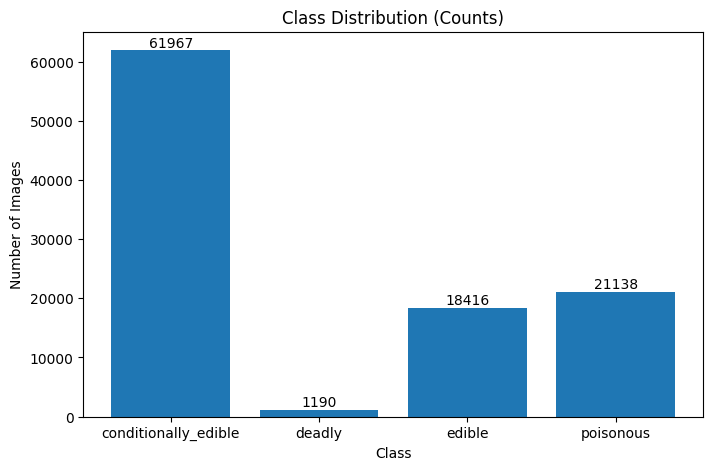

In [21]:
# class Distribution Plot
counts = df["class"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values)

plt.title("Class Distribution (Counts)")
plt.xlabel("Class")
plt.ylabel("Number of Images")

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.show()

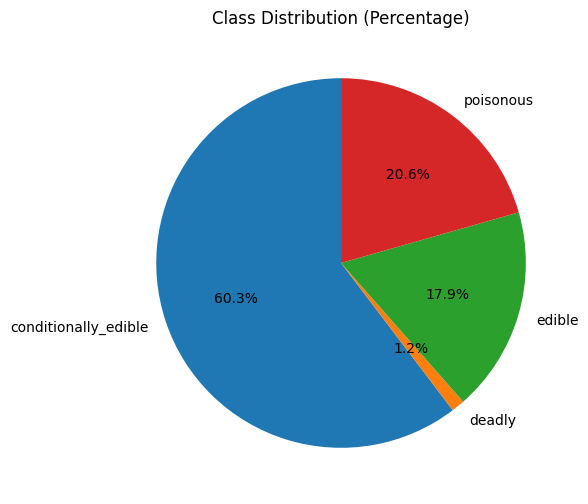

In [22]:
plt.figure(figsize=(6, 6))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Class Distribution (Percentage)")
plt.show()


In [23]:
class_dist_table = (
    counts
    .rename("count")
    .to_frame()
)

class_dist_table["percentage"] = (
    class_dist_table["count"] / class_dist_table["count"].sum() * 100
).round(2)

class_dist_table

,count,percentage
class,,
conditionally_edible,61967,60.33
deadly,1190,1.16
edible,18416,17.93
poisonous,21138,20.58


#### Image Size / Resolution distribution

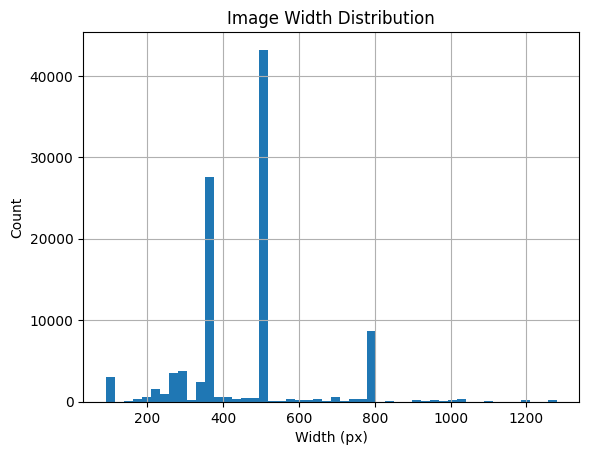

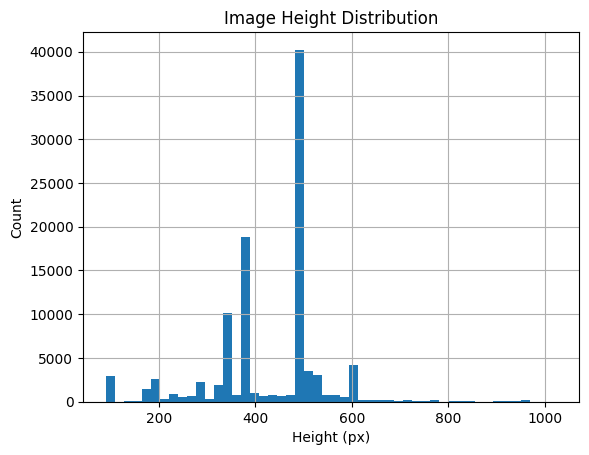

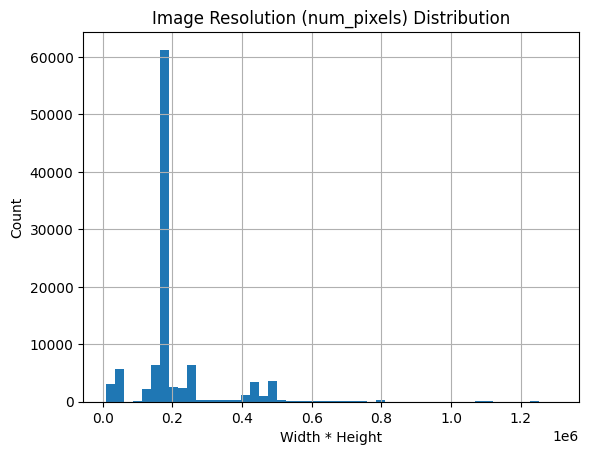

In [24]:
plt.figure()
df["width"].hist(bins=50)
plt.title("Image Width Distribution")
plt.xlabel("Width (px)")
plt.ylabel("Count")
plt.show()

plt.figure()
df["height"].hist(bins=50)
plt.title("Image Height Distribution")
plt.xlabel("Height (px)")
plt.ylabel("Count")
plt.show()

plt.figure()
df["num_pixels"].hist(bins=50)
plt.title("Image Resolution (num_pixels) Distribution")
plt.xlabel("Width * Height")
plt.ylabel("Count")
plt.show()


#### Aspect Ratio + Scatter (spot outliers)

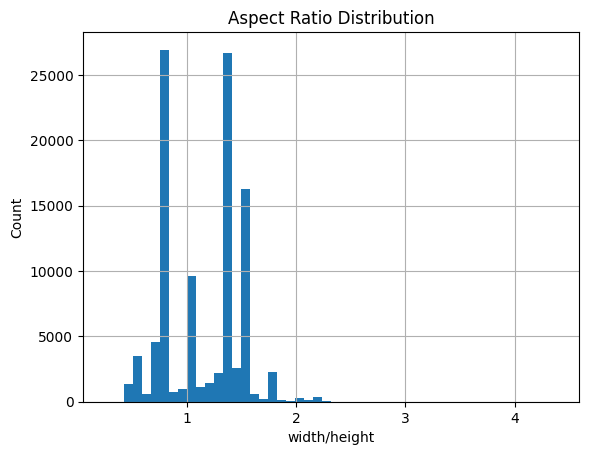

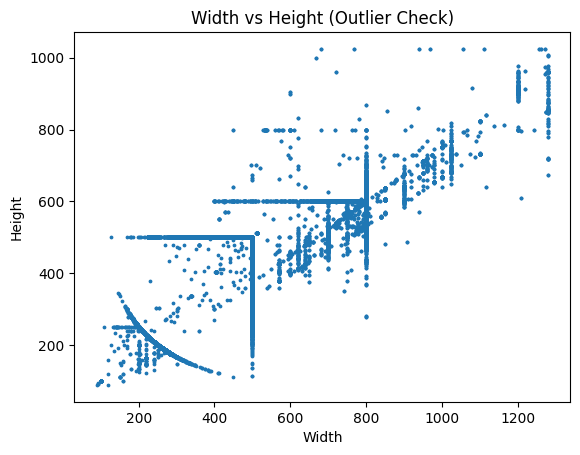

In [25]:
plt.figure()
df["aspect_ratio"].hist(bins=50)
plt.title("Aspect Ratio Distribution")
plt.xlabel("width/height")
plt.ylabel("Count")
plt.show()

# Spot weird sizes/outliers
plt.figure()
plt.scatter(df["width"], df["height"], s=3)
plt.title("Width vs Height (Outlier Check)")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

# Duplicate Check (Exact and Near)

# Duplicate and near-duplicate images were identified and removed to reduce redundancy and prevent df leakage between training and evaluation sets.

## Exact Duplicate Removal 
- Perceptual hash (pHash) values were used to identify exact duplicate images.
- Images sharing the same pHash were considered visually identical.
- For each group of exact duplicates, only the image with the highest resolution (largest number of pixels) was retained.
- Lower-resolution duplicates were removed from the dataset.

## Near-Duplicate Removal
- Near-duplicate images were identified by computing the Hamming distance between pHash values.
- Images with a Hamming distance below a predefined threshold were considered near-duplicates.
- When near-duplicate images were detected, the image with the highest resolution was retained, and remaining lower-resolution images were removed.

In [26]:
# Convert phash objects to strings so they can be compared and sorted
df['phash'] = df['phash'].astype(str)

# Now your original code will work
df_sorted = df.sort_values(["phash", "num_pixels"], ascending=[True, False])

exact_dedup = df_sorted.drop_duplicates(subset=["phash"], keep="first").copy().reset_index(drop=True)

removed = len(df) - len(exact_dedup)
print(f"Rows before: {len(df):,}")
print(f"Rows after : {len(exact_dedup):,}")
print(f"Removed    : {removed:,} ({removed/len(df)*100:.2f}%)")

exact_dedup.to_csv("mushroomDedupExact.csv", index=False)
print("Saved:", "mushroomDedupExact.csv")

Rows before: 102,711
Rows after : 94,698
Removed    : 8,013 (7.80%)
Saved: mushroomDedupExact.csv


In [27]:
HAMMING_THRESHOLD = 5     # 5 means "very similar"
PREFIX_LEN = 4            # bucket by first 4 hex chars; increase to reduce comparisons

In [28]:
# Convert to ImageHash
hashes = df["phash"].astype(str).apply(imagehash.hex_to_hash)

In [29]:
# Bucket indices by hash prefix to avoid O(N^2)
buckets = defaultdict(list)
for i, h in enumerate(hashes):
    buckets[str(h)[:PREFIX_LEN]].append(i)

keep = set(range(len(df)))
dropped = set()

In [30]:
# Within each bucket, drop near-duplicates by keeping highest resolution
for _, idxs in buckets.items():
    if len(idxs) <= 1:
        continue

    idxs_sorted = sorted(idxs, key=lambda i: df.loc[i, "num_pixels"], reverse=True)

    chosen = []
    for i in idxs_sorted:
        if i in dropped:
            continue
        is_near_dup = any((hashes[i] - hashes[j]) <= HAMMING_THRESHOLD for j in chosen)
        if is_near_dup:
            dropped.add(i)
        else:
            chosen.append(i)

In [31]:
keep = sorted(list(keep - dropped))
near_dedup = df.iloc[keep].copy().reset_index(drop=True)

print(f"Rows before: {len(df):,}")
print(f"Rows after : {len(near_dedup):,}")
print(f"Removed    : {len(df)-len(near_dedup):,} ({(len(df)-len(near_dedup))/len(df)*100:.2f}%)")

near_dedup.to_csv("mushroomDedupNear.csv", index=False)
print("Saved:", "mushroomDedupNear.csv")

Rows before: 102,711
Rows after : 94,631
Removed    : 8,080 (7.87%)
Saved: mushroomDedupNear.csv


In [32]:
BASE_DIR = Path(".") 

print("raw :", df.shape)
print("exact:", exact_dedup.shape)
print("near :", near_dedup.shape)

raw : (102711, 11)
exact: (94698, 11)
near : (94631, 11)


In [33]:
def exact_dup_stats(df):
    vc = df["phash"].astype(str).value_counts()
    dup_hashes = (vc > 1).sum()
    dup_images = vc[vc > 1].sum()
    return dup_hashes, dup_images

rows = []
for name, d in [("raw", df), ("after_exact", exact_dedup), ("after_near", near_dedup)]:
    dup_hashes, dup_images = exact_dup_stats(d)
    rows.append({
        "dataset": name,
        "n_rows": len(d),
        "hashes_with_count>1": dup_hashes,
        "images_in_exact_dup_groups": int(dup_images),
        "exact_dup_rate": float(dup_images / len(d))
    })

summary = pd.DataFrame(rows)
summary

,dataset,n_rows,hashes_with_count>1,images_in_exact_dup_groups,exact_dup_rate
0,raw,102711,7623,15636,0.152233
1,after_exact,94698,0,0,0.000000
2,after_near,94631,0,0,0.000000


## Sample of Exact Duplicates Removed

In [34]:
def show_exact_duplicate_group(df, base_dir=BASE_DIR, max_show=6):
    # Count pHash occurrences
    vc = df["phash"].astype(str).value_counts()
    dup_hashes = vc[vc > 1]

    if len(dup_hashes) == 0:
        print("No exact duplicates found.")
        return

    # Take the first duplicate hash as an example
    ph = dup_hashes.index[0]
    group = df[df["phash"].astype(str) == ph].copy()

    # Keep highest-resolution images first
    group = group.sort_values("num_pixels", ascending=False).head(max_show)

    print(f"Example exact-duplicate pHash: {ph}")
    display(group[["file_path", "width", "height", "num_pixels", "class", "species"]])

    plt.figure(figsize=(14, 3))
    for i, (_, row) in enumerate(group.iterrows(), start=1):
        img_path = (base_dir / row["file_path"]).resolve()

        if not img_path.exists():
            raise FileNotFoundError(f"Image not found: {img_path}")

        img = Image.open(img_path).convert("RGB")
        plt.subplot(1, len(group), i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f'{row["width"]}×{row["height"]}')

    plt.show()

## Sample of Near Duplicates Removed


In [35]:
def hamming_hex(h1, h2):
    # robust popcount (works on older Python too)
    x = int(h1, 16) ^ int(h2, 16)
    return bin(x).count("1")

def near_dedup_pairs(df, prefix_len=PREFIX_LEN, thresh=HAMMING_THRESHOLD):
    ph = df["phash"].astype(str).tolist()
    
    buckets = defaultdict(list)
    for idx, h in enumerate(ph):
        buckets[h[:prefix_len]].append(idx)

    # return example near-dup pairs (i, j, distance)
    pairs = []
    for idxs in buckets.values():
        if len(idxs) <= 1:
            continue
        # compare within bucket (still can be big, so we limit example output)
        for a_pos in range(len(idxs)):
            for b_pos in range(a_pos + 1, len(idxs)):
                i, j = idxs[a_pos], idxs[b_pos]
                d = hamming_hex(ph[i], ph[j])
                if d <= thresh and d != 0:  # d==0 are exact duplicates
                    pairs.append((i, j, d))
                    if len(pairs) >= 30:  # limit to keep it fast
                        return pairs
    return pairs

pairs = near_dedup_pairs(df)
print("Found near-duplicate pairs (sample):", len(pairs))
pairs[:5]

Found near-duplicate pairs (sample): 30


[(42230, 42236, 2),
 (87756, 87769, 4),
 (87756, 87775, 4),
 (15525, 72883, 2),
 (62735, 102560, 2)]

In [36]:
def show_near_duplicate_example(df, pairs, base_dir=BASE_DIR):
    if not pairs:
        print("No near-duplicate pairs found (or sampling limit reached).")
        return
    
    i, j, d = pairs[0]
    r1 = df.iloc[i]
    r2 = df.iloc[j]
    print("Example near-duplicate pair")
    print("Hamming distance:", d)
    display(pd.DataFrame([r1, r2])[["file_path", "width", "height", "num_pixels", "class", "species", "phash"]])

    plt.figure(figsize=(8, 4))
    for k, row in enumerate([r1, r2], start=1):
        p = base_dir / row["file_path"]
        img = Image.open(p).convert("RGB")
        plt.subplot(1, 2, k)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f'{row["width"]}x{row["height"]}')
    plt.suptitle(f"Near-duplicate example (Hamming={d})")
    plt.show()


Example near-duplicate pair
Hamming distance: 2


,file_path,width,height,num_pixels,class,species,phash
42230,Classes/conditionally_edible/snakeskin_grisette/13.png,512,512,262144,conditionally_edible,snakeskin_grisette,93cb0de47454ca5b
42236,Classes/conditionally_edible/snakeskin_grisette/6.png,512,512,262144,conditionally_edible,snakeskin_grisette,93cb0de47454ea4b


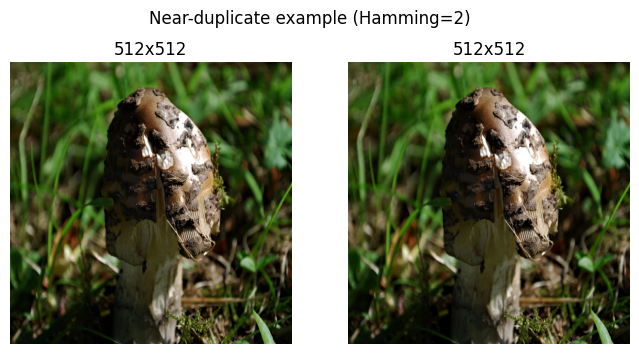

In [37]:
show_near_duplicate_example(df, pairs)

## Summary

In [38]:
dup_counts = df["phash"].value_counts()
num_dup_hashes = (dup_counts > 1).sum()
num_dup_images = dup_counts[dup_counts > 1].sum()

print("Hashes that appear >1 time:", num_dup_hashes)
print("Images involved in duplicates:", num_dup_images)
print("Duplicate image rate:", num_dup_images / len(df))

Hashes that appear >1 time: 7623
Images involved in duplicates: 15636
Duplicate image rate: 0.15223296433682856


## Sample Images per Class (visual sanity check)

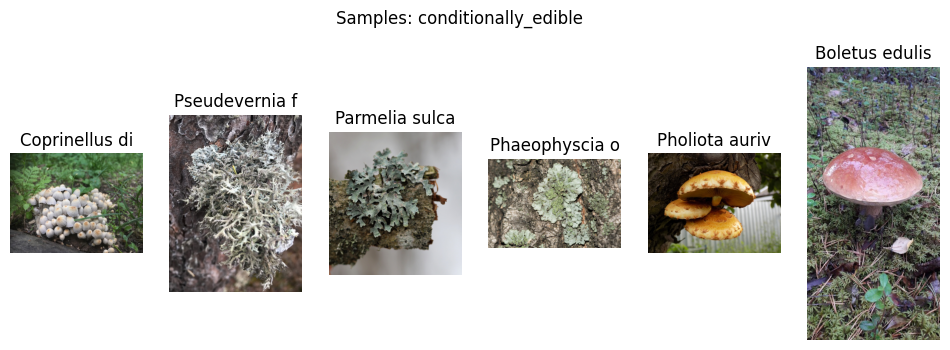

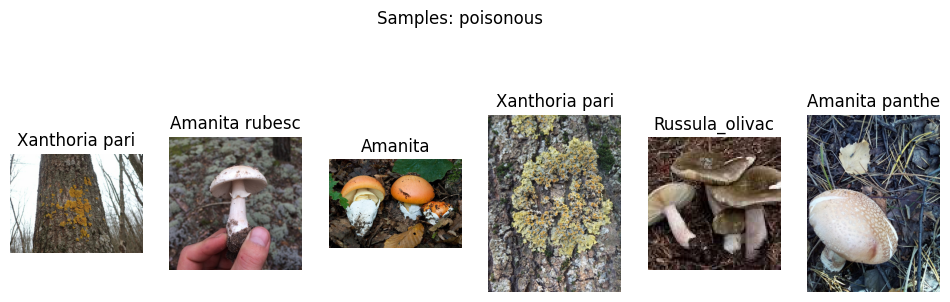

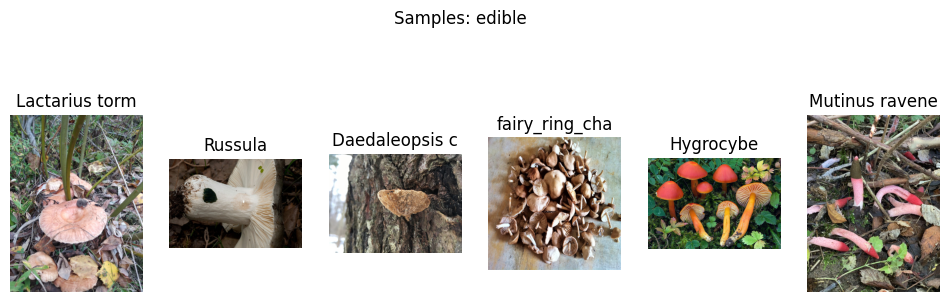

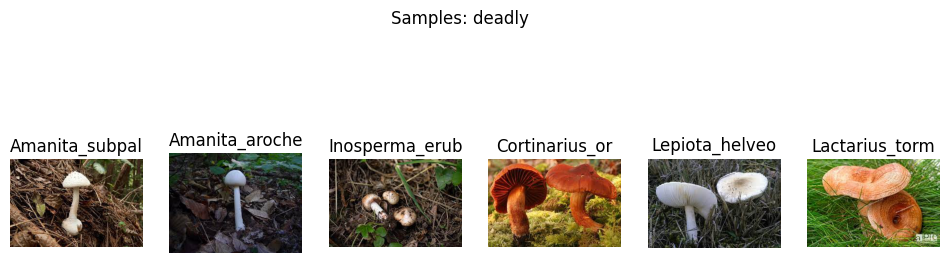

In [39]:
def show_samples(df, class_name, n=6):
    sub = df[df["class"] == class_name].sample(n=min(n, len(df[df["class"] == class_name])), random_state=0)
    plt.figure(figsize=(12, 4))
    for i, (_, row) in enumerate(sub.iterrows(), start=1):
        plt.subplot(1, n, i)
        img = Image.open(row["file_path"]).convert("RGB")
        plt.imshow(img)
        plt.axis("off")
        plt.title(row["species"][:14])
    plt.suptitle(f"Samples: {class_name}")
    plt.show()

for c in df["class"].unique():
    show_samples(df, c, n=6)

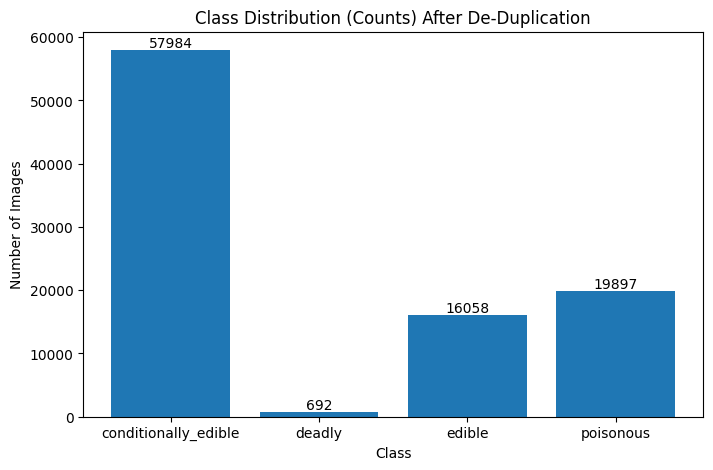

In [40]:
counts = near_dedup["class"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values)

plt.title("Class Distribution (Counts) After De-Duplication")
plt.xlabel("Class")
plt.ylabel("Number of Images")

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.show()

In [41]:
near_dedup['class'].value_counts(normalize=True)

class
conditionally_edible    0.612738
poisonous               0.210259
edible                  0.169691
deadly                  0.007313
Name: proportion, dtype: float64

#### Handling Severe Class Imbalance
 
The **deadly** class represents less than 1% of the total dataset. Such extreme imbalance introduces several issues, such as:
 
* The model may fail to learn meaningful patterns from the **deadly** class as there are not enough images for training.
* Oversampling the minority class could lead to overfitting.
* Undersampling the majority classes will result in significantly less data available for training and testing. 

Thus, we are going to combine the **deadly** class and the **poisonous** class into a single **toxic** category to improve class balance and model stability.

In [42]:
near_dedup['original_class'] = near_dedup['class']
near_dedup['class'] = near_dedup['class'].apply(lambda x: 'toxic' if x == 'poisonous' or x == 'deadly' else x)

In [43]:
near_dedup['class'].value_counts(normalize=True)

class
conditionally_edible    0.612738
toxic                   0.217571
edible                  0.169691
Name: proportion, dtype: float64

In [44]:
near_dedup['original_class'].value_counts(normalize=True)

original_class
conditionally_edible    0.612738
poisonous               0.210259
edible                  0.169691
deadly                  0.007313
Name: proportion, dtype: float64

In [45]:
near_dedup.to_csv("mushroomDedupNearMerged.csv", index=False)

### Data Pipeline & Transformations
#### Standardization
 
Standardization was applied dynamically during df loading to ensure consistent input format for model training. All images were resized to a fixed input resolution to accommodate convolutional neural network requirements. Pixel values were scaled to the range [0, 1] and normalized using predefined channel-wise mean and standard deviation values. This process was deterministic and applied consistently across training, validation, and test datasets.

#### Augmentation
Data augmentation was applied only to the training dataset to improve model robustness and generalization. Random transformations, including horizontal flipping, rotation, and color jittering, were used to introduce controlled variability in image appearance while preserving semantic content. Augmentation was performed at load time and did not modify the original image files.


In [46]:
IMG_SIZE = 224

# RGB statistics of ImageNet
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)


## STRONGER IMG AUGMENTATION FOR RESNET-50 and SWIN. UNCOMMENT AND RUN IF TESTING RESNET-50 and SWIN

In [47]:
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),  
    RandAugment(num_ops=2, magnitude=9),       
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.25),
])


In [48]:
# Run for either model
val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


## Balanced Dataset


In [49]:
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(near_dedup[['file_path']], near_dedup[['class']])

df_balanced = X_res.copy()
df_balanced["class"] = y_res

df_balanced["class"].value_counts()

class
conditionally_edible    16058
edible                  16058
toxic                   16058
Name: count, dtype: int64

# Model
## Train-test-validation Split

In [50]:
near_dedup = pd.read_csv("mushroomDedupNearMerged.csv")

processed_df = near_dedup.copy()

In [51]:
train, temp = train_test_split(df_balanced, test_size=0.2, random_state=42, stratify=df_balanced['class'])
test, val = train_test_split(temp, test_size=0.5, random_state=42, stratify=temp['class'])
train.shape, val.shape, test.shape

((38539, 2), (4818, 2), (4817, 2))

In [52]:
train['class'].value_counts(normalize=True)

class
conditionally_edible    0.333351
edible                  0.333325
toxic                   0.333325
Name: proportion, dtype: float64

In [53]:
test['class'].value_counts(normalize=True)

class
edible                  0.333403
toxic                   0.333403
conditionally_edible    0.333195
Name: proportion, dtype: float64

In [54]:
val['class'].value_counts(normalize=True)

class
toxic                   0.333333
conditionally_edible    0.333333
edible                  0.333333
Name: proportion, dtype: float64

In [55]:
import sys
sys.path.append('/path/to/your/folder')

In [56]:
from torch.utils.data import Dataset
from PIL import Image

class MushroomDataset(Dataset):
    def __init__(self, df, transform=None, class_to_idx=None, classes=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = class_to_idx
        self.classes = classes
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # Load image
        img = Image.open(row['file_path']).convert('RGB')
        
        # Apply transforms
        if self.transform:
            img = self.transform(img)
        
        # Get label
        label = self.class_to_idx[row['class']]
        
        return img, label


In [57]:
train_classes = sorted(train["class"].unique().tolist())
train_class_to_idx = {c: i for i, c in enumerate(train_classes)}

train_ds = MushroomDataset(train, transform=train_tfms, class_to_idx=train_class_to_idx, classes=train_classes)
val_ds = MushroomDataset(val, transform=val_tfms, class_to_idx=train_class_to_idx, classes=train_classes) # ensure same mapping
test_ds = MushroomDataset(test, transform=val_tfms, class_to_idx=train_class_to_idx, classes=train_classes) # ensure same mapping

CLASSES = train_classes

In [58]:
# Use MPS for Apple Silicon, fallback to CPU
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using device: {device}")

Using device: mps


In [59]:
d_device = torch.device(device)
d_device

device(type='mps')

In [60]:
# run this in a new cell
import torch

print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"Current device from your variable: {device}")
print(f"PyTorch default device: {torch.get_default_device()}")

MPS available: True
Current device from your variable: mps
PyTorch default device: cpu


In [61]:
def mps_collate(batch):
    images = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch])
    return images, labels

In [62]:
# simplified DataLoaders 
from torch.utils.data import DataLoader

BATCH_SIZE = 256

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"DataLoaders created:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

DataLoaders created:
   Train batches: 151
   Val batches: 19
   Test batches: 19


In [63]:
# Clear MPS cache before training
torch.mps.empty_cache()
print("MPS cache cleared")

MPS cache cleared


## Class Weights Calculation

## Baseline Model - ResNet50

## Training and Validation

In [64]:
# setup device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using: {device}")

Using: mps


In [65]:
# calculate class weights
counts = train["class"].value_counts().reindex(CLASSES).to_numpy()
counts = torch.tensor(counts, dtype=torch.float)
total = counts.sum()
class_weights = total / (len(CLASSES) * counts)
class_weights = class_weights.to(device)

# create weighted criterion
criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Train counts + weights:")
for c, n, w in zip(CLASSES, counts.tolist(), class_weights.detach().cpu().tolist()):
    print(f"  {c:20s} count={int(n):7d} weight={w:.4f}")


Train counts + weights:
  conditionally_edible count=  12847 weight=0.9999
  edible               count=  12846 weight=1.0000
  toxic                count=  12846 weight=1.0000


## Load Model
### Create model and move to device

In [66]:
# load RESTNET50 model
print("Loading ResNet50...")

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

# count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model device: {next(model.parameters()).device}")

Loading ResNet50...
Total parameters: 23,514,179
Trainable parameters: 23,514,179
Model device: mps:0


### Loss and Optimizer

In [67]:
criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

# different hyperparameters
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)  

In [68]:
print("Running performance check...")
model.train()
for batch_idx, (images, labels) in enumerate(train_loader):
    if batch_idx == 0:
        start = time.time()
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        end = time.time()
        
        print(f"One batch total time: {end-start:.3f} seconds")
        print(f"Images: {images.shape}, Device: {images.device}")
        print(f"Labels: {labels.shape}, Device: {labels.device}")
        break
print("Performance check complete. Starting training...\n")


Running performance check...
One batch total time: 3.416 seconds
Images: torch.Size([256, 3, 224, 224]), Device: mps:0
Labels: torch.Size([256]), Device: mps:0
Performance check complete. Starting training...



## DataLoaders created with MPS generator

In [69]:
print("Model created and moved to device")
print(f"Model device: {next(model.parameters()).device}")

Model created and moved to device
Model device: mps:0


In [70]:
BATCH_SIZE = 256  
NUM_WORKERS = 0   

In [71]:
# define mps_collate function if you want to use it
def mps_collate(batch):
    images = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch])
    return images, labels

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    collate_fn=mps_collate if torch.backends.mps.is_available() else None,
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
    persistent_workers=True if NUM_WORKERS > 0 else False
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    collate_fn=mps_collate if torch.backends.mps.is_available() else None,
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
    persistent_workers=True if NUM_WORKERS > 0 else False
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    collate_fn=mps_collate if torch.backends.mps.is_available() else None,
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
    persistent_workers=True if NUM_WORKERS > 0 else False
)

print(f"DataLoaders created:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

DataLoaders created:
   Batch size: 256
   Train batches: 151
   Val batches: 19
   Test batches: 19


In [72]:
# training setup 
num_epochs = 60
best_val_acc = 0
patience = 8
no_improve_epochs = 0

In [73]:
# optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
warmup = LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=5)
cosine = CosineAnnealingLR(optimizer, T_max=45, eta_min=1e-6)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

In [74]:
print(f"{'Epoch':>5} {'LR':>10} {'Train Loss':>12} {'Train Acc':>10} {'Train Prec':>10} {'Train Rec':>10} {'Train F1':>10} | {'Val Loss':>10} {'Val Acc':>8} {'Val Prec':>8} {'Val Rec':>8} {'Val F1':>8}")
print('-' * 125)

for epoch in range(num_epochs):
    
    # TRAINING SET
    model.train()
    train_loss = 0.0
    train_preds = []
    train_targets = []
    
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())
    
    # compute training metrics
    train_loss = train_loss / len(train_loader.dataset)
    train_acc = accuracy_score(train_targets, train_preds)
    train_prec, train_rec, train_f1, _ = precision_recall_fscore_support(train_targets, train_preds, average='macro', zero_division=0)
    
    # VALIDATION SET
    model.eval()
    val_loss = 0.0
    val_preds = []
    val_targets = []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())
    
    # compute validation metrics
    val_loss = val_loss / len(val_loader.dataset)
    val_acc = accuracy_score(val_targets, val_preds)
    val_prec, val_rec, val_f1, _ = precision_recall_fscore_support(val_targets, val_preds, average='macro', zero_division=0)
    
    # update scheduler
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # print results
    print(f"{epoch+1:5d} {current_lr:10.6f} {train_loss:12.4f} {train_acc:10.4f} {train_prec:10.4f} {train_rec:10.4f} {train_f1:10.4f} | {val_loss:10.4f} {val_acc:8.4f} {val_prec:8.4f} {val_rec:8.4f} {val_f1:8.4f}")
    
    # Check for improvement
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'resnet50_best.pth')
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1
        if no_improve_epochs >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break
    
    # clear MPS cache every 5 epochs
    if (epoch + 1) % 5 == 0 and torch.backends.mps.is_available():
        torch.mps.empty_cache()

print(f"\nTraining finished. Best validation accuracy: {best_val_acc:.4f}")

Epoch         LR   Train Loss  Train Acc Train Prec  Train Rec   Train F1 |   Val Loss  Val Acc Val Prec  Val Rec   Val F1
-----------------------------------------------------------------------------------------------------------------------------


    1   0.000208       0.7861     0.6411     0.6431     0.6411     0.6405 |     0.5942   0.7534   0.7549   0.7534   0.7525


    2   0.000406       0.5745     0.7534     0.7533     0.7534     0.7534 |     0.5126   0.7980   0.8040   0.7980   0.7960


    3   0.000604       0.5382     0.7728     0.7726     0.7728     0.7727 |     0.5354   0.7850   0.8015   0.7850   0.7824


    4   0.000802       0.5422     0.7704     0.7703     0.7704     0.7704 |     0.6782   0.7281   0.7657   0.7281   0.7300


...

   56   0.000044       0.0587     0.9771     0.9771     0.9771     0.9771 |     0.6086   0.8873   0.8874   0.8873   0.8874


   57   0.000059       0.0597     0.9775     0.9775     0.9775     0.9775 |     0.6175   0.8842   0.8844   0.8842   0.8842


   58   0.000077       0.0636     0.9753     0.9753     0.9753     0.9753 |     0.6214   0.8867   0.8867   0.8867   0.8867


   59   0.000096       0.0663     0.9746     0.9747     0.9746     0.9747 |     0.6079   0.8852   0.8853   0.8852   0.8852


   60   0.000118       0.0681     0.9747     0.9747     0.9747     0.9747 |     0.5997   0.8840   0.8846   0.8840   0.8842

Training finished. Best validation accuracy: 0.8890


## Testing

In [75]:
# load the best model
model.load_state_dict(torch.load('resnet50_best.pth'))
model.eval()

# testing
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# calculate metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

test_correct = sum(np.array(all_preds) == np.array(all_labels))
test_total = len(all_labels)
accuracy = 100. * test_correct / test_total
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print("\nResNet50 Test Results:")
print(f"   Total test images: {test_total}")
print(f"   Correct predictions: {test_correct}")
print(f"   Test Accuracy: {accuracy:.2f}%")
print(f"   Precision (macro): {precision:.4f}")
print(f"   Recall (macro): {recall:.4f}")
print(f"   F1-Score (macro): {f1:.4f}")


ResNet50 Test Results:
   Total test images: 4817
   Correct predictions: 4244
   Test Accuracy: 88.10%
   Precision (macro): 0.8813
   Recall (macro): 0.8810
   F1-Score (macro): 0.8811


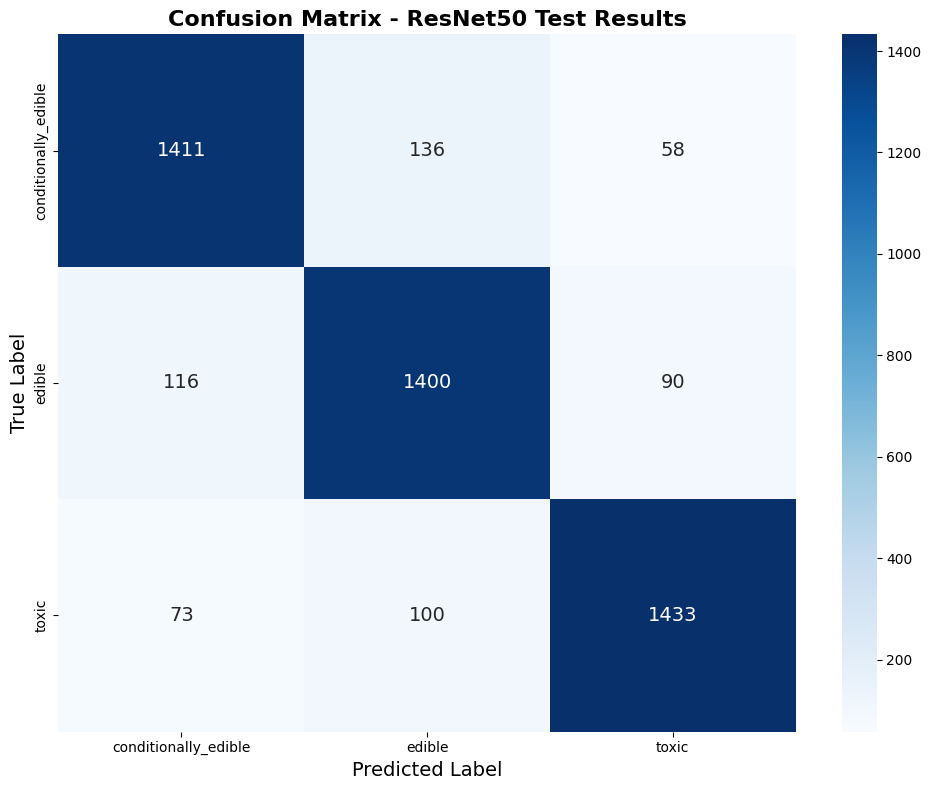

In [77]:
# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
new_class = ['conditionally_edible', 'edible', 'toxic'] 

# Create confusion matrix heatmap (printed first)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=new_class, 
            yticklabels=new_class,
            annot_kws={'size': 14})
plt.title('Confusion Matrix - ResNet50 Test Results', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.tight_layout()
plt.show()

In [78]:
# overall metrics
test_correct = sum(np.array(all_preds) == np.array(all_labels))
test_total = len(all_labels)
accuracy = 100. * test_correct / test_total
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

print("RESNET50 TEST RESULTS")
print(f"Total test images: {test_total}")
print(f"Correct predictions: {test_correct}")
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1-Score (macro): {f1:.4f}")

RESNET50 TEST RESULTS
Total test images: 4817
Correct predictions: 4244
Test Accuracy: 88.10%
Precision (macro): 0.8813
Recall (macro): 0.8810
F1-Score (macro): 0.8811


In [91]:
class_names_list = ['conditionally_edible', 'edible', 'toxic']

print("CONFUSION MATRIX SUMMARY:")

# 2. Loop through the list, NOT a string variable
for i, cls in enumerate(class_names_list):
    total = cm[i].sum()
    correct = cm[i][i]
    accuracy_pct = 100. * correct / total
    
    # This will now print the full category name correctly
    print(f"{cls:20}: {correct:4d}/{total:4d} correct ({accuracy_pct:6.2f}%)")
    
    # 3. Use the same list for the inner loop
    for j, other_class in enumerate(class_names_list):
        if i != j and cm[i][j] > 0:
            misclass_pct = 100. * cm[i][j] / total
            print(f"    Misclassified as {other_class:20}: {cm[i][j]:4d} ({misclass_pct:5.2f}%)")
    print()

CONFUSION MATRIX SUMMARY:
conditionally_edible: 1411/1605 correct ( 87.91%)
    Misclassified as edible              :  136 ( 8.47%)
    Misclassified as toxic               :   58 ( 3.61%)

edible              : 1400/1606 correct ( 87.17%)
    Misclassified as conditionally_edible:  116 ( 7.22%)
    Misclassified as toxic               :   90 ( 5.60%)

toxic               : 1433/1606 correct ( 89.23%)
    Misclassified as conditionally_edible:   73 ( 4.55%)
    Misclassified as edible              :  100 ( 6.23%)

